### **1. Setup**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform


from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    recall_score
)


In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")


RANDOM_STATE = 42
TARGET_COL= "target"
CSV_PATH=r"C:\Users\HP\Desktop\MY PROJECTS\Dr.ML\dataset\heart.csv"

### **2. Load Data**

In [5]:
df = pd.read_csv(CSV_PATH)
print("Dataset shape: ", df.shape)

Dataset shape:  (1025, 14)


In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0


### **3. EDA**

In [7]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal",
    "target"
]

print("Numerical features: ", numerical_features)
print("Categorical features: ", categorical_features)

Numerical features:  ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Categorical features:  ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']


In [8]:
df.isna().sum().sort_values()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
for col in df.columns:
    print(df[col].value_counts().head(10))

age
58    68
57    57
54    53
59    46
52    43
56    39
51    39
62    37
60    37
44    36
Name: count, dtype: int64
sex
1    713
0    312
Name: count, dtype: int64
cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64
trestbps
120    128
130    123
140    107
110     64
150     55
138     45
128     39
125     38
160     36
112     30
Name: count, dtype: int64
chol
204    21
234    21
197    19
212    18
254    17
269    16
240    14
282    14
177    14
226    13
Name: count, dtype: int64
fbs
0    872
1    153
Name: count, dtype: int64
restecg
1    513
0    497
2     15
Name: count, dtype: int64
thalach
162    35
160    31
163    29
152    28
173    28
132    26
144    26
125    25
150    25
143    23
Name: count, dtype: int64
exang
0    680
1    345
Name: count, dtype: int64
oldpeak
0.000    329
1.200     58
1.000     51
0.600     47
0.800     44
1.400     44
1.600     37
0.200     37
1.800     36
2.000     32
Name: count, dtype: int64
slope
1    482
2    469
0     74
N

NOTE: No missing encoded values

In [10]:
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()

print("Number of duplicate rows: ", num_duplicates)

Number of duplicate rows:  723


Although dataset contains a large number of duplicate rows, these likely represent multiple real-world patients with identical clinical measurements. Dropping these rows would drastically reduce the dataset size and distort the natural frequency of observations in the data.

We therefore retain duplicate rows, but take special care during validation. To ensure a fair evaluation, we use group-based splitting(Group K-Fold) so that identical data points are never shared between training and validation folds

While tree-based models are robust to duplicate observations during training, preventing duplicate leakage across folds is essential to obtain reliable and unbiased performance estimates

In [11]:
print(df[TARGET_COL].value_counts())
print("-"*50)
print(df[TARGET_COL].value_counts(normalize=True)*100)

target
1    526
0    499
Name: count, dtype: int64
--------------------------------------------------
target
1   51.317
0   48.683
Name: proportion, dtype: float64


8


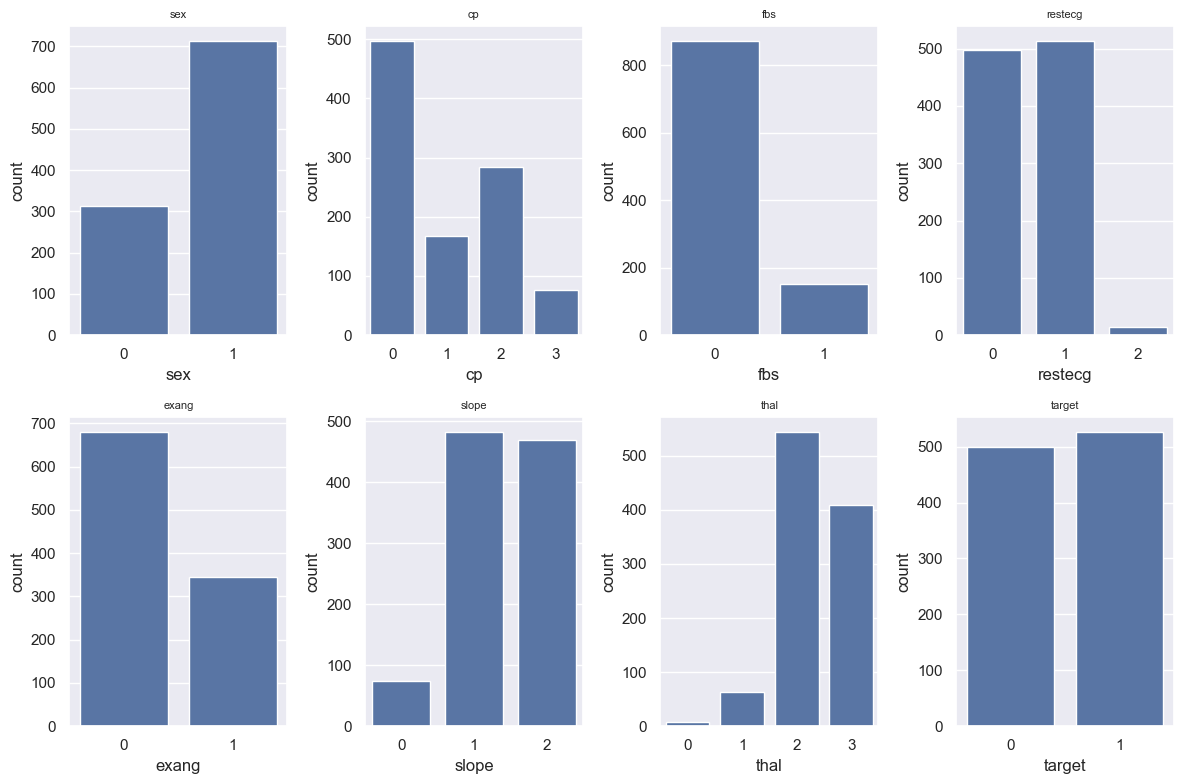

In [12]:
#visualize categorical features
print(len(categorical_features))

fig, axes = plt.subplots(2, 4, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

6


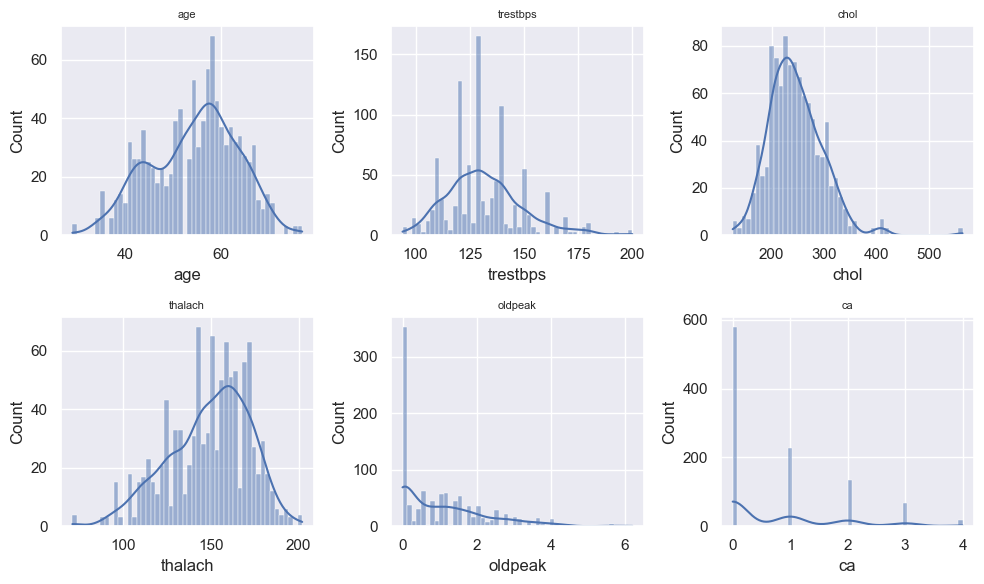

In [13]:
#visualize numerical features
print(len(numerical_features))
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(data=df, x=col, ax=axes[i], bins=50, kde=True)
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

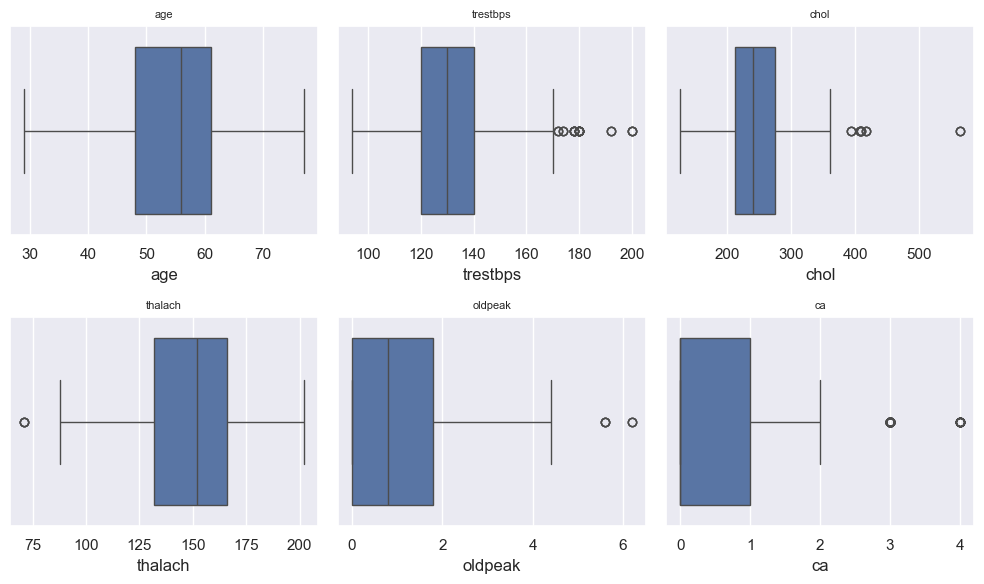

In [14]:
#visualize numerical features
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

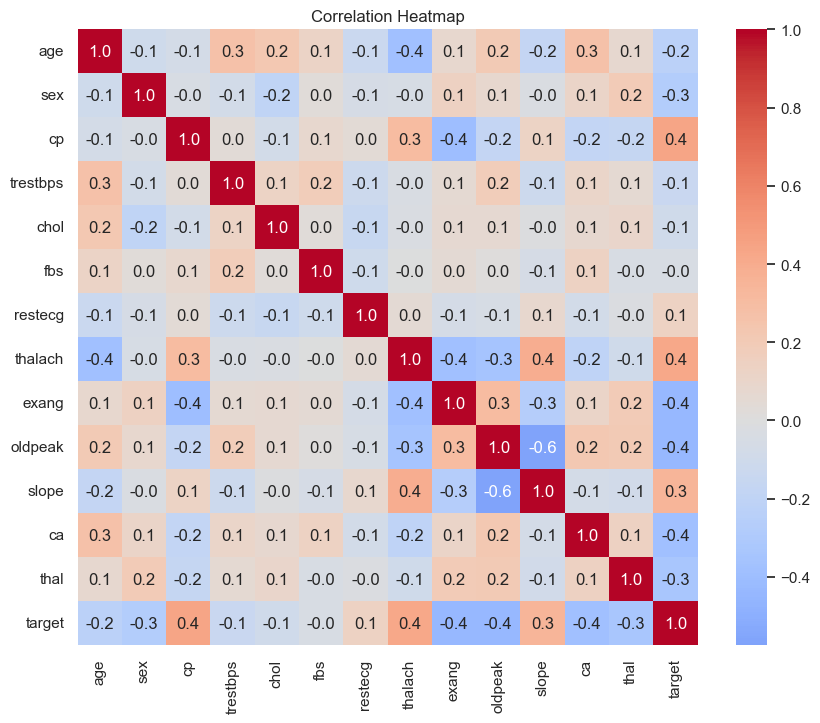

In [15]:
#correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".1f", center=0, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

NO higly related columns

### **4. Data Preprocessing**

In [16]:
X=df.drop(columns=[TARGET_COL])
y=df[TARGET_COL]


# Create a signature for each feature row - to prevent duplicates flow to test set
row_signature = pd.util.hash_pandas_object(X, index=False)

In [17]:
#Split data into train and test sets using GroupShuffleSplit

gss= GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    gss.split(X, y, groups=row_signature)
)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train Shape: ", X_train.shape)
print("Test Shape: ", X_test.shape)


Train Shape:  (817, 13)
Test Shape:  (208, 13)


In [18]:
print("Dataset size: ", X.shape)
print("Training Dataset size: ", X_train.shape)
print("Test Dataset size:", X_test.shape)

Dataset size:  (1025, 13)
Training Dataset size:  (817, 13)
Test Dataset size: (208, 13)


### **5.Baseline Model - LogisticRegression**

In [19]:
baseline_pipe = Pipeline(
    steps = [
    ("scale", StandardScaler()),
    ("model", LogisticRegression())
    ]
)

In [20]:
baseline_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wor

In [21]:
def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name):
    #predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)


    #accuracy
    train_acc = accuracy_score(y_train, y_train_pred)*100
    test_acc = accuracy_score(y_test, y_test_pred)*100

    #results
    print(f"{model_name} - Train Accuracy: {train_acc:.2f}%")
    print(f"{model_name} - Test Accuracy: {test_acc:.2f}%\n")

    print("-"*40)


    print("Train Classification Report")
    print(classification_report(y_train, y_train_pred))


    print("-"*40)


    print("Test Classification Report")
    print(classification_report(y_test, y_test_pred))

In [22]:
evaluate_classifier(
    baseline_pipe,
    X_train,
    y_train,
    X_test,
    y_test,
    "LogisticRegression"
)

LogisticRegression - Train Accuracy: 87.15%
LogisticRegression - Test Accuracy: 82.69%

----------------------------------------
Train Classification Report
              precision    recall  f1-score   support

           0       0.89      0.84      0.87       401
           1       0.85      0.90      0.88       416

    accuracy                           0.87       817
   macro avg       0.87      0.87      0.87       817
weighted avg       0.87      0.87      0.87       817

----------------------------------------
Test Classification Report
              precision    recall  f1-score   support

           0       0.89      0.72      0.80        98
           1       0.79      0.92      0.85       110

    accuracy                           0.83       208
   macro avg       0.84      0.82      0.82       208
weighted avg       0.84      0.83      0.82       208



### **6. Model Selection**

In [23]:
models = {
    "LogisticRegression": LogisticRegression(random_state=RANDOM_STATE),
    "Support Vector Machine": SVC(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGB": XGBClassifier(),
    "HistGB": HistGradientBoostingClassifier(random_state=RANDOM_STATE)
}

In [24]:
groups = pd.util.hash_pandas_object(X_train, index=False)
k = 10
cv=StratifiedGroupKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [25]:
for name, model in models.items():
    accuracy_scores = []
    recall_scores = []
    f1_scores = []

    for tr_idx, te_idx in cv.split(X_train, y_train, groups=groups):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

        pipe = Pipeline(
            steps = [
                ("scale", StandardScaler()),
                ("model", model)
            ]
        )

        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_te)

        accuracy_scores.append(round(accuracy_score(y_te, pred), 2))
        recall_scores.append(round(recall_score(y_te, pred), 2))
        f1_scores.append(round(f1_score(y_te, pred), 2))


    recall_mean = round(float(np.mean(recall_scores)), 4)
    f1_score_mean = round(float(np.mean(f1_scores)), 4)
    accuracy_mean = round(float(np.mean(accuracy_scores)), 4)

    print("Model name: ", name)
    print("Recall values: ", recall_scores)
    print("F1 scores: ", f1_scores)
    print("Accuracy scores: ", accuracy_scores)
    print("\nCV Recall mean: ", recall_mean)
    print("CV F1 score mean: ", f1_score_mean)
    print("CV accuracy score mean: ", accuracy_mean)
    print("Average of 3 values: ", float((recall_mean + f1_score_mean + accuracy_mean) / 3.00))
    print("Median of 3 values: ", float(np.median([recall_mean, f1_score_mean, accuracy_mean])))

    print("-"* 40)


Model name:  LogisticRegression
Recall values:  [0.86, 0.76, 1.0, 0.83, 0.93, 0.93, 0.86, 0.71, 0.86, 0.93]
F1 scores:  [0.89, 0.68, 0.87, 0.79, 0.92, 0.89, 0.88, 0.78, 0.79, 0.89]
Accuracy scores:  [0.89, 0.64, 0.85, 0.78, 0.92, 0.89, 0.88, 0.8, 0.77, 0.88]

CV Recall mean:  0.867
CV F1 score mean:  0.838
CV accuracy score mean:  0.83
Average of 3 values:  0.8450000000000001
Median of 3 values:  0.838
----------------------------------------
Model name:  Support Vector Machine
Recall values:  [0.83, 0.93, 0.85, 0.68, 0.76, 0.93, 0.86, 0.63, 0.79, 0.76]
F1 scores:  [0.88, 0.79, 0.76, 0.67, 0.82, 0.82, 0.85, 0.73, 0.75, 0.74]
Accuracy scores:  [0.88, 0.75, 0.73, 0.65, 0.83, 0.79, 0.84, 0.77, 0.73, 0.73]

CV Recall mean:  0.802
CV F1 score mean:  0.781
CV accuracy score mean:  0.77
Average of 3 values:  0.7843333333333334
Median of 3 values:  0.781
----------------------------------------


Model name:  Random Forest
Recall values:  [0.86, 0.86, 0.93, 0.68, 0.93, 1.0, 0.93, 0.71, 0.79, 0.76]
F1 scores:  [0.89, 0.79, 0.81, 0.7, 0.92, 0.85, 0.92, 0.79, 0.78, 0.82]
Accuracy scores:  [0.89, 0.77, 0.78, 0.7, 0.92, 0.83, 0.91, 0.81, 0.77, 0.83]

CV Recall mean:  0.845
CV F1 score mean:  0.827
CV accuracy score mean:  0.821
Average of 3 values:  0.831
Median of 3 values:  0.827
----------------------------------------
Model name:  XGB
Recall values:  [0.86, 0.86, 0.93, 0.68, 1.0, 0.93, 1.0, 0.78, 0.86, 0.83]
F1 scores:  [0.86, 0.82, 0.78, 0.7, 0.88, 0.82, 0.91, 0.8, 0.83, 0.86]
Accuracy scores:  [0.85, 0.81, 0.73, 0.7, 0.87, 0.79, 0.9, 0.8, 0.81, 0.87]

CV Recall mean:  0.873
CV F1 score mean:  0.826
CV accuracy score mean:  0.813
Average of 3 values:  0.8373333333333332
Median of 3 values:  0.826
----------------------------------------
Model name:  HistGB
Recall values:  [0.86, 0.83, 0.9, 0.68, 0.93, 0.93, 0.93, 0.71, 0.86, 0.76]
F1 scores:  [0.82, 0.8, 0.8, 0.67, 0.88, 0.82, 

### **7. Hyperparameter Tuning**

In [ ]:
rfc_pipe = Pipeline(
    steps = [
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier( #best model by highest median
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

In [27]:
param_dist = {
    "model__n_estimators": randint(400, 1200),
    "model__max_depth": [3, 4, 5, 6],
    "model__min_samples_split": randint(10, 40),
    "model__min_samples_leaf": randint(4, 20),
    "model__max_features": [0.25, 0.35, 0.5, "sqrt"],
    "model__bootstrap": [True],
    "model__max_samples": uniform(0.6, 0.35),
    "model__ccp_alpha": uniform(0.0, 0.02)
}

In [28]:
randomized_search = RandomizedSearchCV(
    estimator=rfc_pipe,
    param_distributions=param_dist,
    n_iter=60,
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_STATE,
    verbose=2,
    n_jobs=-1
)

In [29]:
randomized_search.fit(X_train, y_train, groups=groups)

Fitting 10 folds for each of 60 candidates, totalling 600 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__bootstrap': [True], 'model__ccp_alpha': <scipy.stats....001FADA0DA210>, 'model__max_depth': [3, 4, ...], 'model__max_features': [0.25, 0.35, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation str

In [30]:
print("Hyperparameter tuning results: ")
print("Best f1_macro score: ", randomized_search.best_score_)
print("Best Parameters: ", randomized_search.best_params_)

Hyperparameter tuning results: 
Best f1_macro score:  0.8556750375709242
Best Parameters:  {'model__bootstrap': True, 'model__ccp_alpha': np.float64(0.0036364993441420123), 'model__max_depth': 3, 'model__max_features': 0.25, 'model__max_samples': np.float64(0.7064847850358382), 'model__min_samples_leaf': 9, 'model__min_samples_split': 38, 'model__n_estimators': 1147}


### **8. Retrain model with best parameters**

In [31]:
best_model = Pipeline(
    steps = [
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_jobs=-1,
            bootstrap=randomized_search.best_params_["model__bootstrap"],
            ccp_alpha=randomized_search.best_params_["model__ccp_alpha"],
            max_depth=randomized_search.best_params_["model__max_depth"],
            max_features=randomized_search.best_params_["model__max_features"],
            max_samples=randomized_search.best_params_["model__max_samples"],
            min_samples_leaf=randomized_search.best_params_["model__min_samples_leaf"],
            min_samples_split=randomized_search.best_params_["model__min_samples_split"],
            n_estimators=randomized_search.best_params_["model__n_estimators"],
            random_state=RANDOM_STATE
        ))
    ]
)

In [32]:
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1147
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",38


In [33]:
evaluate_classifier(best_model, X_train, y_train, X_test, y_test, "Tuned Random Forest")

Tuned Random Forest - Train Accuracy: 89.47%
Tuned Random Forest - Test Accuracy: 80.77%

----------------------------------------
Train Classification Report
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       401
           1       0.87      0.94      0.90       416

    accuracy                           0.89       817
   macro avg       0.90      0.89      0.89       817
weighted avg       0.90      0.89      0.89       817

----------------------------------------
Test Classification Report
              precision    recall  f1-score   support

           0       0.88      0.68      0.77        98
           1       0.77      0.92      0.83       110

    accuracy                           0.81       208
   macro avg       0.82      0.80      0.80       208
weighted avg       0.82      0.81      0.80       208



### **9. Build a Predictive System**

In [34]:
def predict_heart_disease(input_features):

    input_df = pd.DataFrame(
        [input_features],
        columns=X_train.columns
    )

    prediction = best_model.predict(input_df)[0]
    probability = best_model.predict_proba(input_df)[0][1]#Check my understanding to ensure, I am getting the right things

    print(f"Predicted class: {prediction}")
    print(f"Heart disease risk probability: {probability:.2%}")

    if prediction == 1:
        print("Diagnosis: High risk of heart disease")
    else:
        print("Diagnosis: Low risk of heart disease")

    return prediction, probability


In [35]:
y_test[y_test==1].head()

24    1
38    1
57    1
68    1
76    1
Name: target, dtype: int64

In [36]:
test1 = X_test.loc[24].tolist()
test1

[42.0, 0.0, 2.0, 120.0, 209.0, 0.0, 1.0, 173.0, 0.0, 0.0, 1.0, 0.0, 2.0]

In [37]:
y_test[y_test==0].head()

4     0
8     0
14    0
17    0
43    0
Name: target, dtype: int64

In [38]:
test2 = X_test.loc[4].to_list()
test2

[62.0, 0.0, 0.0, 138.0, 294.0, 1.0, 1.0, 106.0, 0.0, 1.9, 1.0, 3.0, 2.0]

In [39]:
test1_pred, test1_prob = predict_heart_disease(test1)

Predicted class: 1
Heart disease risk probability: 88.46%
Diagnosis: High risk of heart disease


In [40]:
test2_pred, test2_prob = predict_heart_disease(test2)

Predicted class: 0
Heart disease risk probability: 30.12%
Diagnosis: Low risk of heart disease
